In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("credit_card_fraud_10K.csv")
df

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0


In [3]:
df['merchant_category'].nunique()
df['merchant_category'].value_counts()
 #checking how many tpyes of merchant in the column and how mny times it appears-for a type which may appear less in the column it may not be useful
# If one dominates model may bias toward it


merchant_category
Food           2093
Clothing       2050
Travel         1990
Grocery        1944
Electronics    1923
Name: count, dtype: int64

In [4]:
#creating dummy variables
df_encoded = pd.get_dummies(
    df,
    columns=['merchant_category'],
    prefix='merchant_category'
)
df_encoded = df_encoded.astype(int)


In [5]:
df_encoded.head()


,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud,merchant_category_Clothing,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
0,1,84,22,0,0,66,3,40,0,0,1,0,0,0
1,2,541,3,1,0,87,1,64,0,0,0,0,0,1
2,3,237,17,0,0,49,1,61,0,0,0,0,1,0
3,4,164,4,0,1,72,3,34,0,0,0,0,1,0
4,5,30,15,0,0,79,0,44,0,0,0,1,0,0


In [6]:
df_encoded.columns


Index(['transaction_id', 'amount', 'transaction_hour', 'foreign_transaction',
       'location_mismatch', 'device_trust_score', 'velocity_last_24h',
       'cardholder_age', 'is_fraud', 'merchant_category_Clothing',
       'merchant_category_Electronics', 'merchant_category_Food',
       'merchant_category_Grocery', 'merchant_category_Travel'],
      dtype='object')

In [7]:
df_encoded.shape

(10000, 14)

In [8]:
df_encoded.info()#confimation if its aonly numeric data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   transaction_id                 10000 non-null  int64
 1   amount                         10000 non-null  int64
 2   transaction_hour               10000 non-null  int64
 3   foreign_transaction            10000 non-null  int64
 4   location_mismatch              10000 non-null  int64
 5   device_trust_score             10000 non-null  int64
 6   velocity_last_24h              10000 non-null  int64
 7   cardholder_age                 10000 non-null  int64
 8   is_fraud                       10000 non-null  int64
 9   merchant_category_Clothing     10000 non-null  int64
 10  merchant_category_Electronics  10000 non-null  int64
 11  merchant_category_Food         10000 non-null  int64
 12  merchant_category_Grocery      10000 non-null  int64
 13  merchant_category

In [9]:
print(df_encoded.isnull().sum().sort_values(ascending=False))

transaction_id                   0
amount                           0
transaction_hour                 0
foreign_transaction              0
location_mismatch                0
device_trust_score               0
velocity_last_24h                0
cardholder_age                   0
is_fraud                         0
merchant_category_Clothing       0
merchant_category_Electronics    0
merchant_category_Food           0
merchant_category_Grocery        0
merchant_category_Travel         0
dtype: int64


In [10]:
df_encoded.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud,merchant_category_Clothing,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.456600,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100,0.205000,0.192300,0.209300,0.194400,0.199000
std,2886.89568,175.393796,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957,0.403722,0.394127,0.406829,0.395758,0.399268
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2500.75000,50.000000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5000.50000,122.000000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7500.25000,242.000000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,10000.00000,1471.000000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
df_encoded.skew().sort_values(ascending=False)


is_fraud                         7.953582
location_mismatch                2.960570
foreign_transaction              2.708422
amount                           1.919486
merchant_category_Electronics    1.561737
merchant_category_Grocery        1.544688
merchant_category_Travel         1.508061
merchant_category_Clothing       1.461695
merchant_category_Food           1.429387
velocity_last_24h                0.707884
device_trust_score               0.011191
cardholder_age                   0.003868
transaction_id                   0.000000
transaction_hour                -0.026581
dtype: float64

In [12]:
X = df_encoded.drop(['is_fraud', 'transaction_id'], axis=1)
y = df_encoded['is_fraud']


In [13]:
X.head()

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,merchant_category_Clothing,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
0,84,22,0,0,66,3,40,0,1,0,0,0
1,541,3,1,0,87,1,64,0,0,0,0,1
2,237,17,0,0,49,1,61,0,0,0,1,0
3,164,4,0,1,72,3,34,0,0,0,1,0
4,30,15,0,0,79,0,44,0,0,1,0,0


In [14]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% test, 80% train
    random_state=42,     # for reproducibility
    stratify=y           # preserves class distribution
)

# Optional sanity check
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Fraud proportion in train:", y_train.mean())
print("Fraud proportion in test:", y_test.mean())


Train shape: (8000, 12) (8000,)
Test shape: (2000, 12) (2000,)
Fraud proportion in train: 0.015125
Fraud proportion in test: 0.015


In [15]:
# compute scale_pos-weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print("Scale pos weight:", scale_pos_weight)

Scale pos weight: 65.11570247933884


In [16]:
# THE XGBoost classifier algorithm

model = XGBClassifier(
    n_estimators=300,         # number of trees
    max_depth=6,              # depth of each tree
    learning_rate=0.05,       # step size
    subsample=0.8,            # row sampling
    colsample_bytree=0.8,     # column sampling
    scale_pos_weight=scale_pos_weight,  # handles class imbalance
    eval_metric='logloss',    # suitable for binary classification
    random_state=42
)
# Fit the model
model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [17]:
#model evalluation
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import confusion_matrix

# Predictions (probabilities)
y_probs = model.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_probs)
print("ROC-AUC:", roc_auc) # measures how well the model separates fraud vs non-fraud

# Precision-Recall AUC
pr_auc = average_precision_score(y_test, y_probs)
print("Precision-Recall AUC:", pr_auc) # focuses on fraud detection quality, not overall majority class

# Confusion matrix using default 0.5 threshold
y_pred = (y_probs >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm) #helps with seeing how many frauds are correcly detected

ROC-AUC: 1.0
Precision-Recall AUC: 0.9999999999999999
Confusion Matrix:
 [[1970    0]
 [   0   30]]


In [18]:
from sklearn.model_selection import cross_val_score
#Ensures model generalizes beyond train/test split
scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
print("Cross-validation ROC-AUC:", scores)
print("Mean ROC-AUC:", scores.mean())


Cross-validation ROC-AUC: [0.99835871 1.         1.         1.         0.9998034 ]
Mean ROC-AUC: 0.9996324236849597


In [19]:
#See which features are giving the model “perfect prediction” power
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance)

transaction_hour                 0.190297
location_mismatch                0.165088
velocity_last_24h                0.146207
device_trust_score               0.143060
foreign_transaction              0.142289
amount                           0.044207
merchant_category_Travel         0.042508
merchant_category_Electronics    0.033341
merchant_category_Food           0.030970
merchant_category_Clothing       0.028569
cardholder_age                   0.020082
merchant_category_Grocery        0.013382
dtype: float32


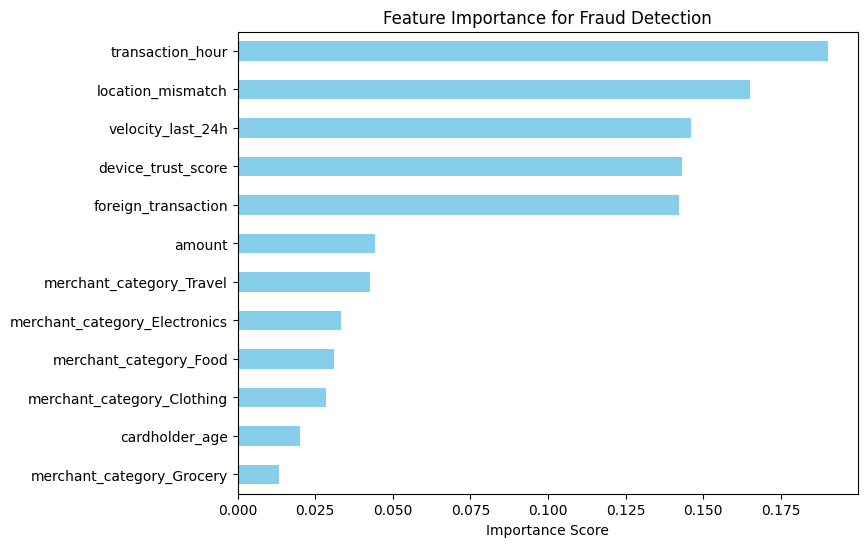

In [20]:
#visualize feature importance
importance.sort_values(ascending=True).plot(kind='barh', figsize=(8,6), color='skyblue')
plt.title("Feature Importance for Fraud Detection")
plt.xlabel("Importance Score")
plt.show()


In [21]:

from sklearn.metrics import precision_score, recall_score, f1_score

y_probs = model.predict_proba(X_test)[:,1]
thresholds = np.arange(0.1, 0.9, 0.05)

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    print(f"Threshold: {t:.2f}, Precision: {precision_score(y_test, y_pred):.2f}, Recall: {recall_score(y_test, y_pred):.2f}, F1: {f1_score(y_test, y_pred):.2f}")


Threshold: 0.10, Precision: 0.81, Recall: 1.00, F1: 0.90
Threshold: 0.15, Precision: 0.88, Recall: 1.00, F1: 0.94
Threshold: 0.20, Precision: 0.97, Recall: 1.00, F1: 0.98
Threshold: 0.25, Precision: 1.00, Recall: 1.00, F1: 1.00
Threshold: 0.30, Precision: 1.00, Recall: 1.00, F1: 1.00
Threshold: 0.35, Precision: 1.00, Recall: 1.00, F1: 1.00
Threshold: 0.40, Precision: 1.00, Recall: 1.00, F1: 1.00
Threshold: 0.45, Precision: 1.00, Recall: 1.00, F1: 1.00
Threshold: 0.50, Precision: 1.00, Recall: 1.00, F1: 1.00
Threshold: 0.55, Precision: 1.00, Recall: 1.00, F1: 1.00
Threshold: 0.60, Precision: 1.00, Recall: 1.00, F1: 1.00
Threshold: 0.65, Precision: 1.00, Recall: 0.97, F1: 0.98
Threshold: 0.70, Precision: 1.00, Recall: 0.97, F1: 0.98
Threshold: 0.75, Precision: 1.00, Recall: 0.97, F1: 0.98
Threshold: 0.80, Precision: 1.00, Recall: 0.97, F1: 0.98
Threshold: 0.85, Precision: 1.00, Recall: 0.97, F1: 0.98


In [22]:
threshold = 0.25
y_pred = (y_probs >= threshold).astype(int)

from sklearn.metrics import precision_score, recall_score, f1_score
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))


Precision: 1.0
Recall: 1.0
F1-score: 1.0


In [23]:
import joblib

# Save model
joblib.dump(model, "xgboost_fraud_model.pkl")


['xgboost_fraud_model.pkl']

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_final = (model.predict_proba(X_test)[:,1] >= 0.25).astype(int)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("\nClassification Report:\n", classification_report(y_test, y_pred_final, target_names=['Non-Fraud', 'Fraud']))


Confusion Matrix:
 [[1970    0]
 [   0   30]]

Classification Report:
               precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00      1970
       Fraud       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



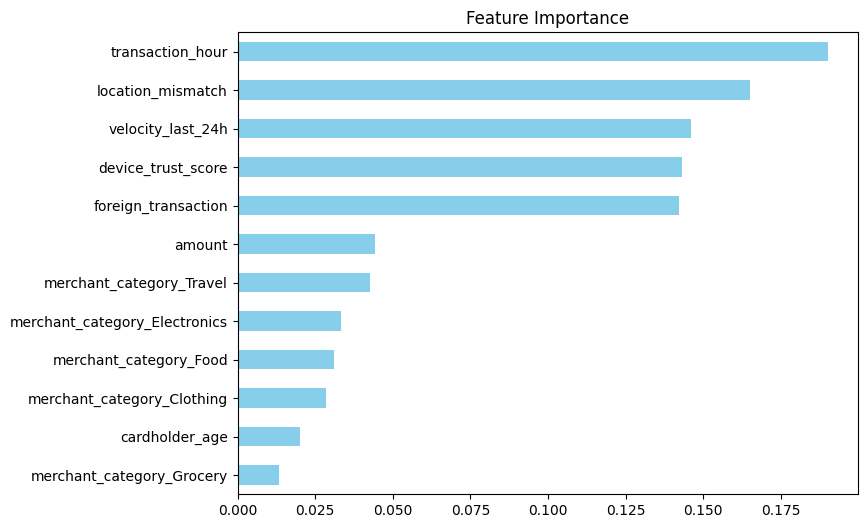

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
importance.plot(kind='barh', figsize=(8,6), color='skyblue')
plt.title("Feature Importance")
plt.show()
